## Importation

In [2]:
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    balanced_accuracy_score, confusion_matrix, classification_report,
    roc_curve, accuracy_score, auc,
)

from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv

import optuna

/home/yona/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Graph Preparation 

In [4]:
DATA_ROOT = '/media/Data/Yona/WSI CCRCC'

# 1) Load embeddings
with open(f'{DATA_ROOT}/embeddings_train.pkl', 'rb') as f:
    train_data = pickle.load(f)
with open(f'{DATA_ROOT}/embeddings_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_train = np.array(train_data['embeddings'])
patient_ids_train = np.array(train_data['patient_ids'])

X_test = np.array(test_data['embeddings'])
patient_ids_test = np.array(test_data['patient_ids'])

X_all = np.concatenate([X_train, X_test], axis=0)
patient_ids_all = np.concatenate([patient_ids_train, patient_ids_test], axis=0)

unique_pids = np.unique(patient_ids_all)
num_patients = len(unique_pids)
pid_to_idx = {pid: idx for idx, pid in enumerate(unique_pids)}

# 2) Build heterograph
data = HeteroData()

data['image'].x = torch.tensor(X_all, dtype=torch.float)
data['patient'].x = torch.zeros((num_patients, 1), dtype=torch.float)

source_nodes, target_nodes = [], []
for img_idx, pid in enumerate(patient_ids_all):
    source_nodes.append(img_idx)
    target_nodes.append(pid_to_idx[pid])
data['image', 'to', 'patient'].edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)

print(f"Total number of 'image' nodes : {data['image'].num_nodes}")
print(f"Total number of 'patient' nodes: {data['patient'].num_nodes}")
print(f"Number of edges image→patient  : {data['image', 'to', 'patient'].edge_index.shape[1]}")

# 3) Load and assign clinical/genomic features
df = pd.read_csv(f'{DATA_ROOT}/medical_genomic_data/clinical+genomic_split.csv', index_col='case_id')
df['age_diag'] = df['age_diag'].fillna(df['age_diag'].mean())
df['cancer_history'] = df['cancer_history'].fillna(0)

df_features = df.drop(columns=['vital_status_12', 'Split'])

missing = set(unique_pids) - set(df_features.index)
if missing:
    raise KeyError(f"The following patient IDs are missing from the CSV: {missing}")

df_features = df_features.loc[unique_pids]
data['patient'].x = torch.tensor(df_features.values, dtype=torch.float)

print(f"Shape of data['patient'].x : {data['patient'].x.shape}")
print(f"First patient ({unique_pids[0]}) → features: {data['patient'].x[0][:5]}")

# 4) Load labels and create masks
labels = df.loc[unique_pids, 'vital_status_12'].astype(int).values
split  = df.loc[unique_pids, 'Split'].values

data['patient'].y          = torch.tensor(labels, dtype=torch.long)
data['patient'].train_mask = torch.tensor(split == 'train')
data['patient'].val_mask   = torch.tensor(split == 'validation')
data['patient'].test_mask  = torch.tensor(split == 'test')

print(f"Labels shape: {data['patient'].y.shape}")
print(f"Number of train patients: {data['patient'].train_mask.sum().item()}")
print(f"Number of val patients:   {data['patient'].val_mask.sum().item()}")
print(f"Number of test patients:  {data['patient'].test_mask.sum().item()}")

Total number of 'image' nodes : 2134
Total number of 'patient' nodes: 617
Number of edges image→patient  : 2134
Shape of data['patient'].x : torch.Size([617, 17])
First patient (C3L-00004) → features: tensor([1., 6., 3., 0., 7.])
Labels shape: torch.Size([617])
Number of train patients: 472
Number of val patients:   25
Number of test patients:  120


## Grill search 

In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class HeteroGNN_SAGE(torch.nn.Module):
    def __init__(self, in_img: int, in_pat: int, hidden_dim: int, dropout_p: float, num_classes: int):
        super().__init__()
        self.lin_img = torch.nn.Linear(in_img, hidden_dim)
        self.lin_pat = torch.nn.Linear(in_pat, hidden_dim)

        self.conv1 = HeteroConv(
            {('image', 'to', 'patient'): SAGEConv((hidden_dim, hidden_dim), hidden_dim, aggr='mean')},
            aggr='sum'
        )
        self.conv2 = HeteroConv(
            {('image', 'to', 'patient'): SAGEConv((hidden_dim, hidden_dim), hidden_dim, aggr='mean')},
            aggr='sum'
        )

        self.lin_hidden = torch.nn.Linear(hidden_dim, hidden_dim)
        self.dropout = torch.nn.Dropout(p=dropout_p)
        self.lin_out = torch.nn.Linear(hidden_dim, num_classes)

    def forward(self, x_dict, edge_index_dict):
        x_img = F.relu(self.lin_img(x_dict['image']))
        x_pat = F.relu(self.lin_pat(x_dict['patient']))

        h1 = F.relu(self.conv1({'image': x_img, 'patient': x_pat}, edge_index_dict)['patient'] + x_pat)
        h2 = F.relu(self.conv2({'image': x_img, 'patient': h1}, edge_index_dict)['patient'] + h1)

        h = self.dropout(F.relu(self.lin_hidden(h2)))
        return self.lin_out(h)


# DATA / MASKS
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

train_mask = data['patient'].train_mask.to(device)
val_mask   = data['patient'].val_mask.to(device)
test_mask  = data['patient'].test_mask.to(device)
y_all      = data['patient'].y.to(device)

x_dict = data.x_dict
edge_index_dict = data.edge_index_dict

in_img = data['image'].num_node_features
in_pat = data['patient'].num_node_features
num_classes = 2

class_w = torch.tensor([9.0, 1.0], device=device)


def train_one_model(model, optimizer, loss_fn, num_epochs: int, train_mask_):
    model.train()
    for _ in range(num_epochs):
        optimizer.zero_grad()
        logits = model(x_dict, edge_index_dict)[train_mask_]
        loss = loss_fn(logits, y_all[train_mask_])
        loss.backward()
        optimizer.step()


@torch.no_grad()
def eval_bacc(model, mask_) -> float:
    model.eval()
    logits = model(x_dict, edge_index_dict)[mask_]
    preds = logits.argmax(dim=1)
    return balanced_accuracy_score(y_all[mask_].cpu().numpy(), preds.cpu().numpy())


def build_patient_mask_from_indices(idxs: np.ndarray, num_patients: int, device_) -> torch.Tensor:
    mask = torch.zeros(num_patients, dtype=torch.bool)
    mask[idxs] = True
    return mask.to(device_)


def objective(trial: optuna.Trial) -> float:
    set_seed(42)

    hidden_dim = trial.suggest_int("hidden_dim", 48, 96, step=16)
    dropout_p  = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)
    lr         = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    epochs     = trial.suggest_int("epochs", 40, 120, step=10)

    train_idx   = torch.where(train_mask)[0].detach().cpu().numpy()
    y_train_np  = y_all[train_mask].detach().cpu().numpy()

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    num_patients_total = data['patient'].num_nodes

    for fold_id, (tr_i, va_i) in enumerate(skf.split(train_idx, y_train_np), start=1):
        set_seed(42 + fold_id)

        fold_train_mask = build_patient_mask_from_indices(train_idx[tr_i], num_patients_total, device)
        fold_val_mask   = build_patient_mask_from_indices(train_idx[va_i], num_patients_total, device)

        model = HeteroGNN_SAGE(in_img, in_pat, hidden_dim, dropout_p, num_classes).to(device)
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_w)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_one_model(model, optimizer, loss_fn, epochs, fold_train_mask)

        fold_scores.append(eval_bacc(model, fold_val_mask))

    return float(np.mean(fold_scores))


sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=40)

print("\nBest 5-Fold CV TRAIN BACC:", study.best_value)
print("Best params:", study.best_params)


# FINAL TRAINING: train on TRAIN+VAL, evaluate on TEST
best = study.best_params
set_seed(42)

final_model = HeteroGNN_SAGE(
    in_img, in_pat,
    hidden_dim=best["hidden_dim"],
    dropout_p=best["dropout"],
    num_classes=num_classes
).to(device)

final_loss_fn = torch.nn.CrossEntropyLoss(weight=class_w)
final_opt = torch.optim.Adam(final_model.parameters(), lr=best["lr"])

trainval_mask = train_mask | val_mask
train_one_model(final_model, final_opt, final_loss_fn, best["epochs"], trainval_mask)

bacc_test = eval_bacc(final_model, test_mask)
print("\nFinal TEST BACC (train+val retrain):", bacc_test)

[I 2026-06-08 17:49:28,355] A new study created in memory with name: no-name-e5ae77d2-62d7-432c-8b7b-6095ec55c316
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type


Best 5-Fold CV TRAIN BACC: 0.7154993160054719
Best params: {'hidden_dim': 64, 'dropout': 0.30000000000000004, 'lr': 0.0007429905898738971, 'epochs': 50}

Final TEST BACC (train+val retrain): 0.6298076923076923


## Model 

In [8]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class HeteroGNN_SAGE(torch.nn.Module):
    def __init__(self, in_img: int, in_pat: int, hidden_dim: int, dropout_p: float, num_classes: int):
        super().__init__()
        self.lin_img = torch.nn.Linear(in_img, hidden_dim)
        self.lin_pat = torch.nn.Linear(in_pat, hidden_dim)

        self.conv1 = HeteroConv(
            {('image', 'to', 'patient'): SAGEConv((hidden_dim, hidden_dim), hidden_dim, aggr='mean')},
            aggr='sum'
        )
        self.conv2 = HeteroConv(
            {('image', 'to', 'patient'): SAGEConv((hidden_dim, hidden_dim), hidden_dim, aggr='mean')},
            aggr='sum'
        )

        self.lin_hidden = torch.nn.Linear(hidden_dim, hidden_dim)
        self.dropout = torch.nn.Dropout(p=dropout_p)
        self.lin_out = torch.nn.Linear(hidden_dim, num_classes)

    def forward(self, x_dict, edge_index_dict):
        x_img = F.relu(self.lin_img(x_dict['image']))
        x_pat = F.relu(self.lin_pat(x_dict['patient']))

        h1 = F.relu(self.conv1({'image': x_img, 'patient': x_pat}, edge_index_dict)['patient'] + x_pat)
        h2 = F.relu(self.conv2({'image': x_img, 'patient': h1}, edge_index_dict)['patient'] + h1)

        h = self.dropout(F.relu(self.lin_hidden(h2)))
        return self.lin_out(h)



/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(


Epoch 001 | TrainVal Loss: 0.7414 | Val Loss: 0.6470 | TrainVal Acc: 0.3078 | Val Acc: 0.8800
Epoch 010 | TrainVal Loss: 0.5635 | Val Loss: 0.5172 | TrainVal Acc: 0.5674 | Val Acc: 0.5200
Epoch 020 | TrainVal Loss: 0.3971 | Val Loss: 0.5205 | TrainVal Acc: 0.7907 | Val Acc: 0.6000
Epoch 030 | TrainVal Loss: 0.3584 | Val Loss: 0.2635 | TrainVal Acc: 0.7807 | Val Acc: 0.8000
Epoch 040 | TrainVal Loss: 0.2762 | Val Loss: 0.2826 | TrainVal Acc: 0.9135 | Val Acc: 0.8000
Epoch 050 | TrainVal Loss: 0.1702 | Val Loss: 0.1401 | TrainVal Acc: 0.9115 | Val Acc: 0.8800
Epoch 060 | TrainVal Loss: 0.1685 | Val Loss: 0.0763 | TrainVal Acc: 0.8974 | Val Acc: 0.9200
Epoch 070 | TrainVal Loss: 0.1510 | Val Loss: 0.0812 | TrainVal Acc: 0.9034 | Val Acc: 0.9200
Epoch 080 | TrainVal Loss: 0.0991 | Val Loss: 0.0556 | TrainVal Acc: 0.9678 | Val Acc: 0.9600
Epoch 090 | TrainVal Loss: 0.2910 | Val Loss: 0.2258 | TrainVal Acc: 0.8290 | Val Acc: 0.8800
Epoch 100 | TrainVal Loss: 0.1386 | Val Loss: 0.1481 | Train

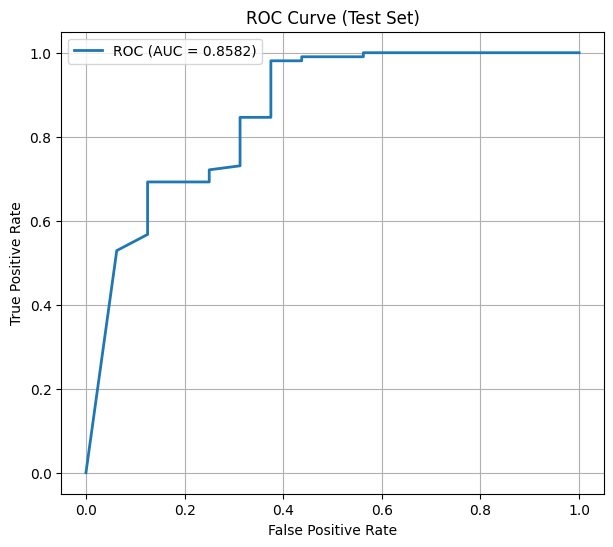

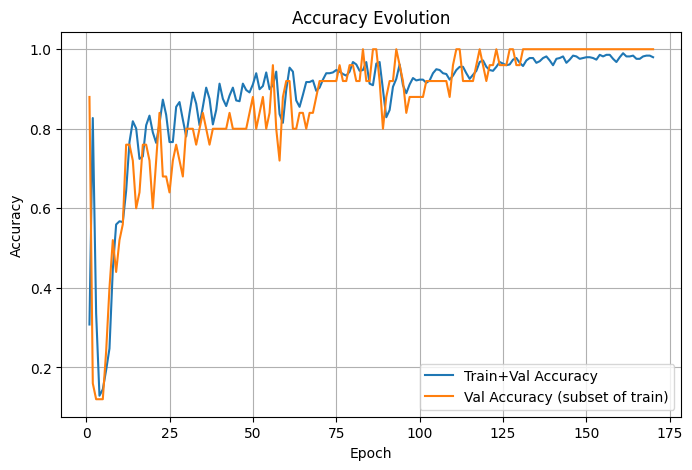

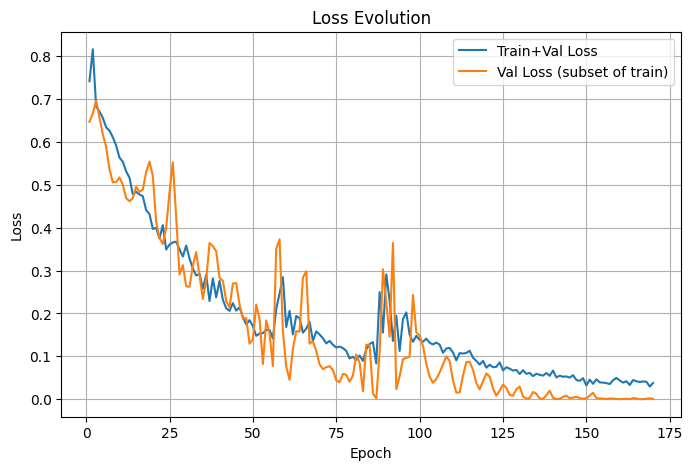


Confusion Matrix (Counts):
[[ 10   6]
 [  2 102]]

Classification Report:
                  precision    recall  f1-score   support

Non-survival (0)       0.83      0.62      0.71        16
    Survival (1)       0.94      0.98      0.96       104

        accuracy                           0.93       120
       macro avg       0.89      0.80      0.84       120
    weighted avg       0.93      0.93      0.93       120



In [9]:
BEST_HIDDEN_DIM = 48
BEST_DROPOUT    = 0.5
BEST_LR         = 0.00853618986286683
BEST_EPOCHS     = 170

# DATA / DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

x_dict          = data.x_dict
edge_index_dict = data.edge_index_dict

train_mask = data['patient'].train_mask.to(device)
val_mask   = data['patient'].val_mask.to(device)
test_mask  = data['patient'].test_mask.to(device)
y_all      = data['patient'].y.to(device)

in_img      = data['image'].num_node_features
in_pat      = data['patient'].num_node_features
num_classes = 2

set_seed(42)

weight_tensor = torch.tensor([9.0, 1.0], device=device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weight_tensor)

model = HeteroGNN_SAGE(
    in_img=in_img,
    in_pat=in_pat,
    hidden_dim=BEST_HIDDEN_DIM,
    dropout_p=BEST_DROPOUT,
    num_classes=num_classes,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=BEST_LR)

# NOTE: model is trained on trainval_mask (train+val) but val curves below
# are computed on val_mask which is included in training — they reflect
# training loss on that subset, not genuine generalization.
trainval_mask = train_mask | val_mask

loss_history, train_acc_history = [], []
val_loss_history, val_acc_history = [], []

for epoch in range(1, BEST_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    logits = model(x_dict, edge_index_dict)
    loss = loss_fn(logits[trainval_mask], y_all[trainval_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        trainval_preds = logits[trainval_mask].argmax(dim=1)
        trainval_acc = accuracy_score(
            y_all[trainval_mask].cpu().numpy(),
            trainval_preds.cpu().numpy(),
        )

        val_logits = model(x_dict, edge_index_dict)[val_mask]
        val_loss = loss_fn(val_logits, y_all[val_mask]).item()
        val_acc = accuracy_score(
            y_all[val_mask].cpu().numpy(),
            val_logits.argmax(dim=1).cpu().numpy(),
        )

    loss_history.append(loss.item())
    train_acc_history.append(trainval_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"TrainVal Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"TrainVal Acc: {trainval_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

# FINAL TEST EVALUATION
model.eval()
with torch.no_grad():
    test_logits = model(x_dict, edge_index_dict)[test_mask]
    test_probs  = torch.softmax(test_logits, dim=1)[:, 1].cpu().numpy()
    test_preds  = test_logits.argmax(dim=1).cpu().numpy()
    test_labels = y_all[test_mask].cpu().numpy()

test_bacc = balanced_accuracy_score(test_labels, test_preds)
test_acc  = accuracy_score(test_labels, test_preds)

print(f"\nFinal TEST Accuracy: {test_acc:.4f}")
print(f"Final TEST Balanced Accuracy: {test_bacc:.4f}")

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {roc_auc:.4f})")
plt.title("ROC Curve (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, BEST_EPOCHS + 1), train_acc_history, label="Train+Val Accuracy")
plt.plot(range(1, BEST_EPOCHS + 1), val_acc_history, label="Val Accuracy (subset of train)")
plt.title("Accuracy Evolution")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, BEST_EPOCHS + 1), loss_history, label="Train+Val Loss")
plt.plot(range(1, BEST_EPOCHS + 1), val_loss_history, label="Val Loss (subset of train)")
plt.title("Loss Evolution")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix (Counts):")
print(cm)

print("\nClassification Report:")
print(classification_report(
    test_labels, test_preds,
    target_names=["Non-survival (0)", "Survival (1)"],
))